In [2]:
import os
import sys

REPO = "/content/diffusion-vs-flow-matching"

if not os.path.exists(REPO):
    !git clone https://github.com/carlosordonezz/diffusion-vs-flow-matching.git {REPO}
else:
    !git -C {REPO} pull  # already cloned: just bring the latest changes

%cd {REPO}
sys.path.insert(0, f"{REPO}/src")  # let Python find the dvfm package

Cloning into '/content/diffusion-vs-flow-matching'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 166 (delta 81), reused 128 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 6.27 MiB | 24.79 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/diffusion-vs-flow-matching


In [3]:
import torch

from dvfm.models import TimeEmbeddingMLP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

# Quick test: your 2D model running on the GPU
model = TimeEmbeddingMLP().to(device)
x = torch.randn(16, 2, device=device)
t = torch.rand(16, device=device)
print("Output:", model(x, t).shape, "on", model(x, t).device)

Device: cuda
GPU: Tesla T4
Output: torch.Size([16, 2]) on cuda:0


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


Shape: torch.Size([60000, 1, 28, 28])
Range: -1.0 to 1.0


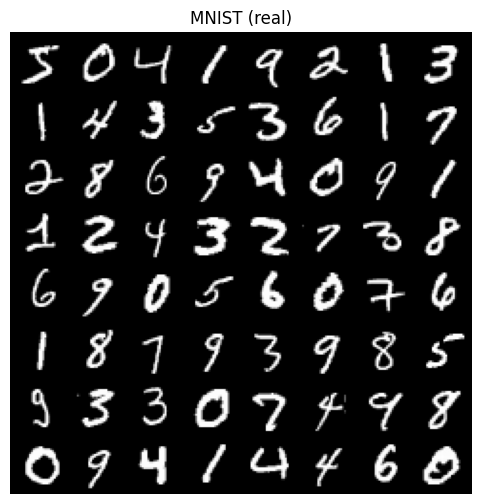

In [4]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from dvfm.data import load_mnist

images = load_mnist()
print("Shape:", images.shape)
print("Range:", images.min().item(), "to", images.max().item())

grid = make_grid(images[:64], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("MNIST (real)")
plt.show()

In [5]:
from dvfm.models import UNet

unet = UNet().to(device)
num_params = sum(p.numel() for p in unet.parameters())
print(f"Parameters: {num_params / 1e6:.2f}M")

x = torch.randn(8, 1, 28, 28, device=device)
t = torch.rand(8, device=device)
with torch.no_grad():
    out = unet(x, t)
print("Input: ", x.shape)
print("Output:", out.shape)

Parameters: 2.77M
Input:  torch.Size([8, 1, 28, 28])
Output: torch.Size([8, 1, 28, 28])


In [6]:
from dvfm.data import load_mnist
from dvfm.ddpm import DDPMSchedule, ddim_sample, ddpm_loss, ddpm_sample
from dvfm.flow_matching import flow_matching_loss
from dvfm.flow_matching import sample as fm_sample
from dvfm.models import TimeEmbeddingMLP, UNet

schedule = DDPMSchedule()
images = load_mnist()
batch = images[:16].to(device)
unet = UNet().to(device)
img_shape = (1, 28, 28)

# --- Images on GPU (untrained network, only checking shapes and devices) ---
print("FM loss:  ", flow_matching_loss(unet, batch).item())
print("DDPM loss:", ddpm_loss(unet, schedule, batch).item())
print("FM sample:  ", fm_sample(unet, 4, num_steps=5, shape=img_shape, device=device).shape)
print("DDIM sample:", ddim_sample(unet, schedule, 4, num_steps=5, clip=1.0, shape=img_shape, device=device).shape)
print("DDPM sample:", ddpm_sample(unet, schedule, 4, shape=img_shape, device=device).shape)

# --- 2D points on CPU (checking the old notebooks still work) ---
mlp = TimeEmbeddingMLP()
print("2D FM sample:  ", fm_sample(mlp, 10, num_steps=3).shape)
print("2D DDPM sample:", ddpm_sample(mlp, schedule, 10).shape)

FM loss:   2.068857431411743
DDPM loss: 1.1629762649536133
FM sample:   torch.Size([4, 1, 28, 28])
DDIM sample: torch.Size([4, 1, 28, 28])
DDPM sample: torch.Size([4, 1, 28, 28])
2D FM sample:   torch.Size([10, 2])
2D DDPM sample: torch.Size([10, 2])


In [7]:
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

CKPT_DIR = Path("/content/drive/MyDrive/dvfm_checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR = Path("/content/diffusion-vs-flow-matching/assets")
print("Checkpoints will be saved in:", CKPT_DIR)

Mounted at /content/drive
Checkpoints will be saved in: /content/drive/MyDrive/dvfm_checkpoints


In [8]:
from dvfm.train import train_model

images_gpu = images.to(device)  # the whole dataset fits on the GPU (~190 MB)
img_shape = (1, 28, 28)

fm_path = CKPT_DIR / "fm_mnist.pt"
torch.manual_seed(0)
fm_unet = UNet().to(device)

if fm_path.exists():
    fm_unet.load_state_dict(torch.load(fm_path, map_location=device))
    fm_unet.eval()
    print("Loaded", fm_path.name)
else:
    fm_losses = train_model(
        fm_unet,
        images_gpu,
        flow_matching_loss,
        num_steps=10_000,
        batch_size=128,
        lr=2e-4,
        log_every=1000,
        cosine_schedule=True,
    )
    torch.save(fm_unet.state_dict(), fm_path)
    print("Saved", fm_path.name)

step     0 | loss 1.9150
step  1000 | loss 0.1985
step  2000 | loss 0.1925
step  3000 | loss 0.1856
step  4000 | loss 0.1678
step  5000 | loss 0.1712
step  6000 | loss 0.1751
step  7000 | loss 0.1724
step  8000 | loss 0.1716
step  9000 | loss 0.1837
Saved fm_mnist.pt


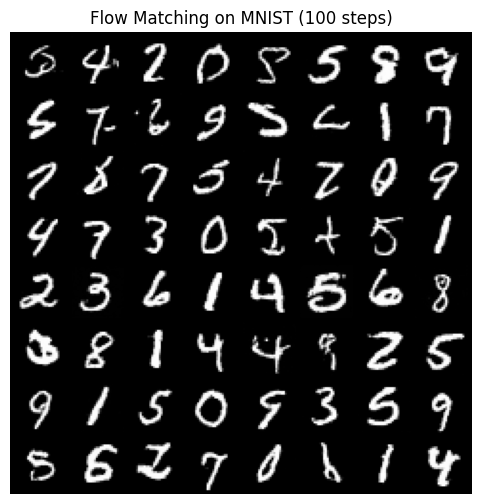

In [9]:
from torchvision.utils import make_grid, save_image


def show_grid(x: torch.Tensor, title: str, path: Path | None = None) -> None:
    """Show (and optionally save) a grid of images in [-1, 1]."""
    x = x.clamp(-1, 1).cpu()
    grid = make_grid(x, nrow=8, normalize=True, value_range=(-1, 1))
    if path is not None:
        save_image(grid, path)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()


fm_unet.eval()
torch.manual_seed(0)
generated = fm_sample(fm_unet, 64, num_steps=100, shape=img_shape, device=device)
show_grid(generated, "Flow Matching on MNIST (100 steps)", ASSETS_DIR / "fm_mnist_samples.png")

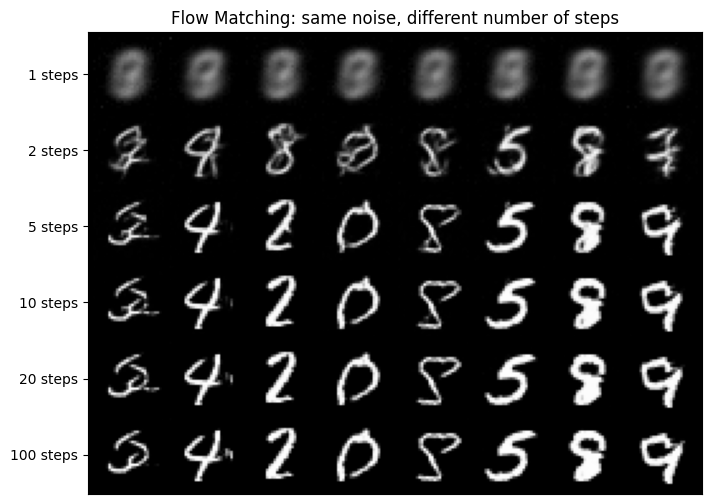

In [13]:
steps_list = [1, 2, 5, 10, 20, 100]
rows = []
for steps in steps_list:
    torch.manual_seed(0)  # same starting noise in every row
    rows.append(fm_sample(fm_unet, 8, num_steps=steps, shape=img_shape, device=device).cpu())

grid = make_grid(torch.cat(rows).clamp(-1, 1), nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(8, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.yticks([16 + 30 * i for i in range(len(steps_list))], [f"{s} steps" for s in steps_list])
plt.xticks([])
plt.title("Flow Matching: same noise, different number of steps")
plt.savefig(ASSETS_DIR / "fm_mnist_steps.png", dpi=150, bbox_inches="tight")  # save the full figure, with labels
plt.show()

In [14]:
from google.colab import files

files.download(str(ASSETS_DIR / "fm_mnist_samples.png"))
files.download(str(ASSETS_DIR / "fm_mnist_steps.png"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>